In [1]:
import os, sys, numpy as np, pandas as pd

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap

CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

# Populate precomputed attributions
raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n][keep]
    em.attr_hyp[ct] = hyp; em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n][keep]

print(f'{len(df)} seqs loaded')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
56975 seqs loaded


In [2]:
import pickle

eigen_cache = os.path.join(REPO, 'genomic_targets', 'data', 'eigen_analysis.pkl')
with open(eigen_cache, 'rb') as f:
    cached = pickle.load(f)

ei1_var = cached['ei1_var']
corrs = cached['corrs']
eixr = ei1_var * corrs
print(f'EIxr: n={len(eixr)}, mean={eixr.mean():.3f}, median={np.median(eixr):.3f}, '
      f'min={eixr.min():.3f}, max={eixr.max():.3f}')

EIxr: n=56975, mean=0.434, median=0.444, min=-0.785, max=0.977


In [3]:
LIB_PATH = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/virtual_perturbations/libraries/hippo_target_library.pkl'
with open(LIB_PATH, 'rb') as f:
    target_lib = pickle.load(f)

focused = target_lib['df']
focus_idx = focused['seq_idx'].values

print(f'Selected library: {len(focus_idx)} sequences')

Selected library: 1059 sequences


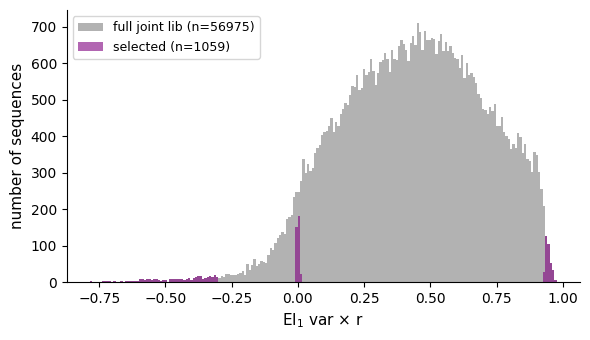

In [4]:
import matplotlib.pyplot as plt

# Distribution of EI_1 var x r: full joint library vs selected (focused) library
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(eixr, bins=200, color='gray', alpha=0.6, label=f'full joint lib (n={len(eixr)})')
ax.hist(eixr[focus_idx], bins=200, color='purple', alpha=0.6, label=f'selected (n={len(focus_idx)})')
ax.set_xlabel('EI$_1$ var $\\times$ r', fontsize=11)
ax.set_ylabel('number of sequences', fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

EI lib size:    1059
p-val lib size: 956  (p<0.05 & |log2FC|>2.0, either direction)
  HepG2-up: 678,  K562-up: 278
  note: fewer qualifying elements than EI lib (956 < 1059) — using all qualifiers


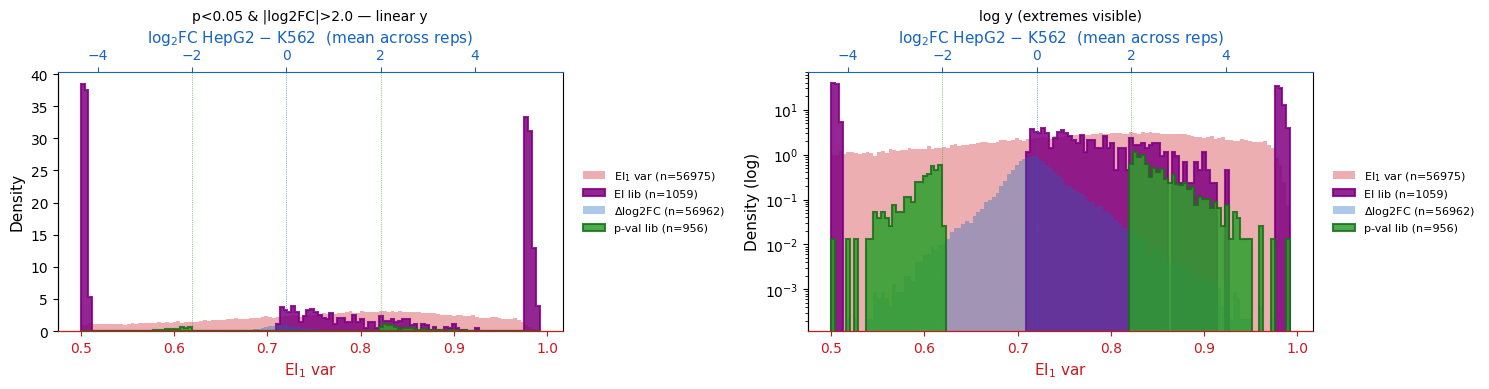

overlap between EI lib and p-val lib: 146


In [5]:
import glob
from scipy.stats import ttest_ind

# Per-replicate log2_ratio -> log2FC diff (HepG2 - K562) per element + Welch p.
MPRA_DIR = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/data/full_joint_mpra'
COLS = ['cell', 'rep', 'name', 'dna', 'rna', 'ratio', 'log2_ratio', 'n_bc']

def _load(cell):
    frames = [pd.read_csv(f, sep='\t', header=None, names=COLS)
              for f in sorted(glob.glob(f'{MPRA_DIR}/{cell}/{cell}_rep*.tsv'))]
    return pd.concat(frames, ignore_index=True)

hep_w = _load('HepG2').pivot_table(index='name', columns='rep', values='log2_ratio')
k_w   = _load('K562' ).pivot_table(index='name', columns='rep', values='log2_ratio')
shared = hep_w.index.intersection(k_w.index)
H, K = hep_w.loc[shared].values, k_w.loc[shared].values
ok = np.isfinite(H).all(1) & np.isfinite(K).all(1)
_, pv = ttest_ind(H[ok], K[ok], axis=1, equal_var=False)
diff_by_name = dict(zip(shared[ok], H[ok].mean(1) - K[ok].mean(1)))
pval_by_name = dict(zip(shared[ok], pv))

diffs = df['name'].map(diff_by_name).values.astype(float)
pvals = df['name'].map(pval_by_name).values.astype(float)
finite = np.isfinite(diffs) & np.isfinite(pvals)

fmask = np.zeros(len(df), dtype=bool); fmask[focus_idx] = True

# "p-val lib": all elements passing p<0.05 AND |log2FC|>1 (either direction).
# If fewer than the EI lib size we just use what we have — no padding.
P_THRESH, LFC_THRESH = 0.05, 2.0
qualifies = finite & (pvals < P_THRESH) & (np.abs(diffs) > LFC_THRESH)
bioinfo_idx = np.where(qualifies)[0]
n_qual = qualifies.sum()
bmask = qualifies.copy()

print(f'EI lib size:    {len(focus_idx)}')
print(f'p-val lib size: {n_qual}  (p<{P_THRESH} & |log2FC|>{LFC_THRESH}, either direction)')
print(f'  HepG2-up: {(bmask & (diffs > 0)).sum()},  K562-up: {(bmask & (diffs < 0)).sum()}')
if n_qual < len(focus_idx):
    print(f'  note: fewer qualifying elements than EI lib ({n_qual} < {len(focus_idx)}) — using all qualifiers')

def _draw(ax, log_y=False):
    ax.hist(ei1_var, bins=120, color='#cb181d', alpha=0.35, density=True,
            label=f'EI$_1$ var (n={len(ei1_var)})')
    ax.hist(ei1_var[focus_idx], bins=120, color='purple', alpha=0.85, density=True,
            histtype='stepfilled', edgecolor='purple', linewidth=1.5,
            label=f'EI lib (n={len(focus_idx)})', zorder=3)
    ax.set_xlabel('EI$_1$ var', color='#cb181d', fontsize=11)
    ax.tick_params(axis='x', colors='#cb181d')
    ax.set_ylabel('Density' + (' (log)' if log_y else ''), fontsize=11)
    if log_y:
        ax.set_yscale('log')
    ax.spines['top'].set_visible(False)

    ax2 = ax.twiny()
    ax2.hist(diffs[finite], bins=120, color='#1565C0', alpha=0.35, density=True,
             label=f'$\\Delta$log2FC (n={finite.sum()})')
    ax2.hist(diffs[bmask], bins=120, color='#2ca02c', alpha=0.85, density=True,
             histtype='stepfilled', edgecolor='#1a6d1a', linewidth=1.5,
             label=f'p-val lib (n={n_qual})', zorder=3)
    ax2.axvline(0, color='#1565C0', lw=0.5, ls=':')
    ax2.axvline( LFC_THRESH, color='#2ca02c', lw=0.5, ls=':')
    ax2.axvline(-LFC_THRESH, color='#2ca02c', lw=0.5, ls=':')
    ax2.set_xlabel('log$_2$FC HepG2 $-$ K562  (mean across reps)', color='#1565C0', fontsize=11)
    ax2.tick_params(axis='x', colors='#1565C0')
    ax2.spines['top'].set_color('#1565C0')
    ax2.spines['bottom'].set_color('#cb181d')
    ax2.spines['right'].set_visible(False)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, frameon=False,
              loc='center left', bbox_to_anchor=(1.02, 0.5))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
_draw(axes[0], log_y=False)
axes[0].set_title(f'p<{P_THRESH} & |log2FC|>{LFC_THRESH} — linear y', fontsize=10)
_draw(axes[1], log_y=True)
axes[1].set_title('log y (extremes visible)', fontsize=10)
plt.tight_layout()
plt.show()

overlap = np.intersect1d(focus_idx, bioinfo_idx).size
print(f'overlap between EI lib and p-val lib: {overlap}')

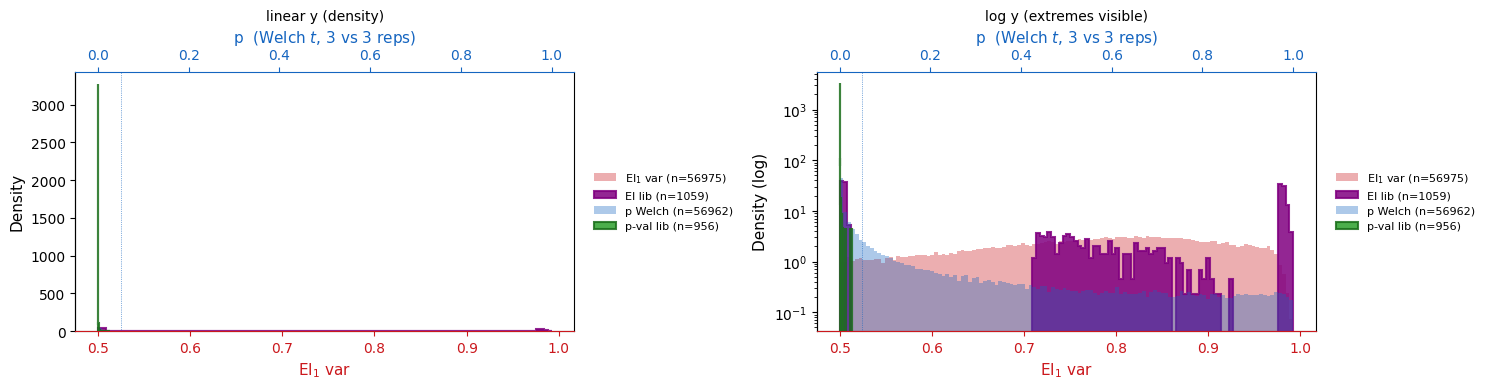

In [6]:
# Compare methods: EI lib (purple, EI_1 var axis) vs p-val lib (green, p axis).
# Recompute pvals from df + pval_by_name so the array length matches df.
pvals = df['name'].map(pval_by_name).values.astype(float)
finite_p = np.isfinite(pvals)

def _draw_p(ax, log_y=False):
    ax.hist(ei1_var, bins=120, color='#cb181d', alpha=0.35, density=True,
            label=f'EI$_1$ var (n={len(ei1_var)})')
    ax.hist(ei1_var[focus_idx], bins=120, color='purple', alpha=0.85, density=True,
            histtype='stepfilled', edgecolor='purple', linewidth=1.5,
            label=f'EI lib (n={len(focus_idx)})', zorder=3)
    ax.set_xlabel('EI$_1$ var', color='#cb181d', fontsize=11)
    ax.tick_params(axis='x', colors='#cb181d')
    ax.set_ylabel('Density' + (' (log)' if log_y else ''), fontsize=11)
    if log_y:
        ax.set_yscale('log')
    ax.spines['top'].set_visible(False)

    ax2 = ax.twiny()
    ax2.hist(pvals[finite_p], bins=120, color='#1565C0', alpha=0.35, density=True,
             label=f'p Welch (n={finite_p.sum()})')
    ax2.hist(pvals[bioinfo_idx], bins=120, color='#2ca02c', alpha=0.85, density=True,
             histtype='stepfilled', edgecolor='#1a6d1a', linewidth=1.5,
             label=f'p-val lib (n={len(bioinfo_idx)})', zorder=3)
    ax2.axvline(0.05, color='#1565C0', lw=0.5, ls=':')
    ax2.set_xlabel('p  (Welch $t$, 3 vs 3 reps)', color='#1565C0', fontsize=11)
    ax2.tick_params(axis='x', colors='#1565C0')
    ax2.spines['top'].set_color('#1565C0')
    ax2.spines['bottom'].set_color('#cb181d')
    ax2.spines['right'].set_visible(False)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, frameon=False,
              loc='center left', bbox_to_anchor=(1.02, 0.5))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
_draw_p(axes[0], log_y=False)
axes[0].set_title('linear y (density)', fontsize=10)
_draw_p(axes[1], log_y=True)
axes[1].set_title('log y (extremes visible)', fontsize=10)
plt.tight_layout()
plt.show()

diff log2FC: n=56975, mean=0.010, median=-0.051, min=-4.354, max=5.368


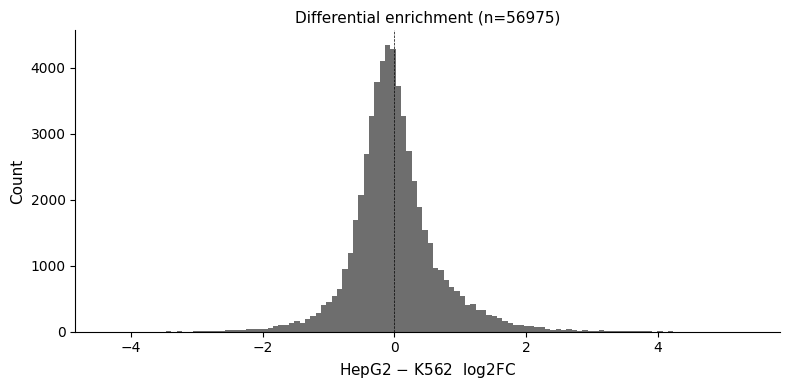

In [7]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence', 'HepG2_log2FC', 'K562_log2FC']).reset_index(drop=True)

# Standard lentiMPRA differential enrichment: HepG2_log2FC - K562_log2FC
diff = (df['HepG2_log2FC'] - df['K562_log2FC']).values
print(f'diff log2FC: n={len(diff)}, mean={diff.mean():.3f}, median={np.median(diff):.3f}, '
      f'min={diff.min():.3f}, max={diff.max():.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(diff, bins=120, color='#555555', alpha=0.85)
ax.axvline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('HepG2 $-$ K562  log2FC', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title(f'Differential enrichment (n={len(diff)})', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

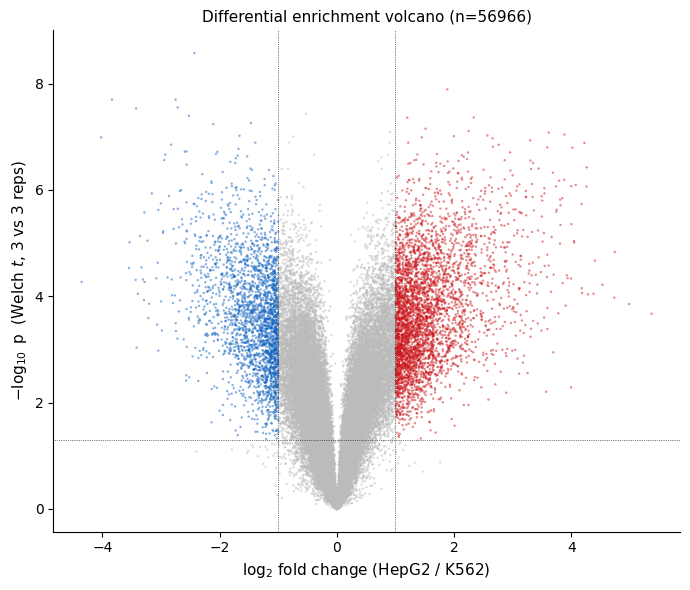

HepG2-enriched (|log2FC|>1, p<0.05): 3905
K562-enriched  (|log2FC|>1, p<0.05): 2392
ns                                 : 50669


In [8]:
import glob
from scipy.stats import ttest_ind

# Real volcano using per-replicate ENCODE element quantifications (3 reps x 2 cell lines).
# TSV cols (no header): cell_line, replicate, name, DNA_norm, RNA_norm, ratio, log2_ratio, n_barcodes
MPRA_DIR = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/data/full_joint_mpra'
COLS = ['cell', 'rep', 'name', 'dna', 'rna', 'ratio', 'log2_ratio', 'n_bc']

def load_cell(cell):
    frames = []
    for f in sorted(glob.glob(f'{MPRA_DIR}/{cell}/{cell}_rep*.tsv')):
        t = pd.read_csv(f, sep='\t', header=None, names=COLS)
        frames.append(t.assign(rep=t['rep'].astype(int)))
    return pd.concat(frames, ignore_index=True)

hep = load_cell('HepG2'); k = load_cell('K562')
hep_w = hep.pivot_table(index='name', columns='rep', values='log2_ratio')
k_w   = k.pivot_table(index='name', columns='rep', values='log2_ratio')

shared = hep_w.index.intersection(k_w.index)
H = hep_w.loc[shared].values   # (N, 3)
K = k_w.loc[shared].values     # (N, 3)
mask = np.isfinite(H).all(1) & np.isfinite(K).all(1)
H, K, names = H[mask], K[mask], shared[mask]

log2fc = H.mean(1) - K.mean(1)
tstat, pvals = ttest_ind(H, K, axis=1, equal_var=False)
nlp = -np.log10(np.clip(pvals, 1e-300, 1.0))

sig = (pvals < 0.05) & (np.abs(log2fc) > 1)
colors = np.where(sig & (log2fc > 0), '#cb181d',
          np.where(sig & (log2fc < 0), '#1565C0', '#bbbbbb'))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(log2fc, nlp, s=3, c=colors, alpha=0.5, edgecolors='none', rasterized=True)
ax.axvline(1, color='k', lw=0.5, ls=':')
ax.axvline(-1, color='k', lw=0.5, ls=':')

ax.axhline(-np.log10(0.05), color='k', lw=0.5, ls=':')
ax.set_xlabel('log$_2$ fold change (HepG2 / K562)', fontsize=11)
ax.set_ylabel('$-\\log_{10}$ p  (Welch $t$, 3 vs 3 reps)', fontsize=11)
ax.set_title(f'Differential enrichment volcano (n={len(log2fc)})', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'HepG2-enriched (|log2FC|>1, p<0.05): {((log2fc > 0) & sig).sum()}')
print(f'K562-enriched  (|log2FC|>1, p<0.05): {((log2fc < 0) & sig).sum()}')
print(f'ns                                 : {(~sig).sum()}')

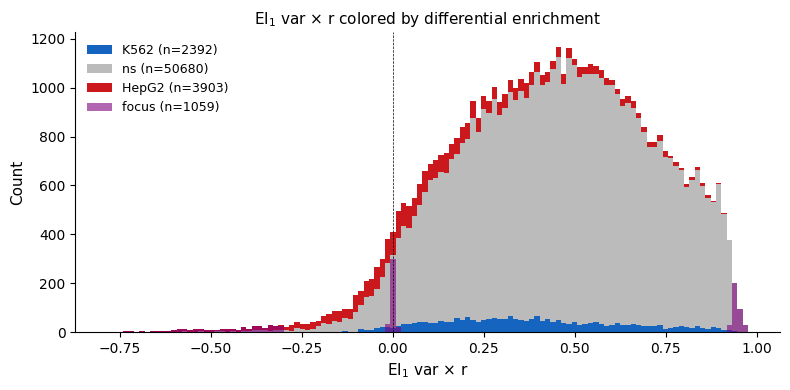

In [9]:
# EIxr distribution stacked by volcano class, with focus subset overlaid in purple.
name_to_class = {}
for nm, lfc, s in zip(names, log2fc, sig):
    if s and lfc > 0:
        name_to_class[nm] = 'HepG2'
    elif s and lfc < 0:
        name_to_class[nm] = 'K562'
    else:
        name_to_class[nm] = 'ns'

cls = df['name'].map(name_to_class).fillna('ns').values

bins = np.linspace(eixr.min(), eixr.max(), 121)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist([eixr[cls == 'K562'], eixr[cls == 'ns'], eixr[cls == 'HepG2']],
        bins=bins, stacked=True,
        color=['#1565C0', '#bbbbbb', '#cb181d'],
        label=[f'K562 (n={(cls=="K562").sum()})',
               f'ns (n={(cls=="ns").sum()})',
               f'HepG2 (n={(cls=="HepG2").sum()})'])

if 'focus_idx' in globals() and len(focus_idx) > 0:
    ax.hist(eixr[focus_idx], bins=bins, color='purple', alpha=0.6,
            label=f'focus (n={len(focus_idx)})')

ax.axvline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('EI$_1$ var $\\times$ r', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('EI$_1$ var $\\times$ r colored by differential enrichment', fontsize=11)
ax.legend(fontsize=9, frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

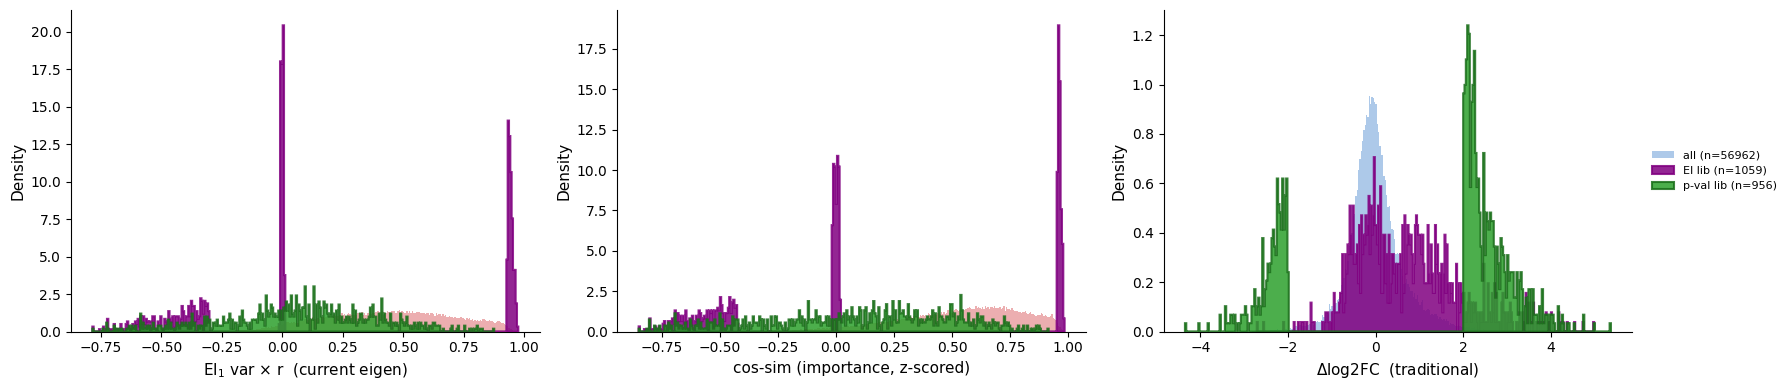

metric                                       all      EI lib   p-val lib
EI_1 var x r  (current eigen)              0.444       0.000       0.089
cos-sim (importance, z-scored)             0.567       0.000       0.154
\Deltalog2FC  (traditional)               -0.051       0.606       2.204


In [10]:
# Three metrics for cell-type regulatory divergence, with EI lib (purple)
# + p-val lib (green) overlaid on each so we can compare what each metric flags:
#   1. current eigen     : EI_1 var x r          (eixr, already cached)
#   2. new cos-sim       : EigenMap.cosine_similarity(mode='importance')
#                          low / negative = divergent between cell types
#   3. traditional MPRA  : log2FC HepG2 - K562   (diffs)

cossim = em.cosine_similarity(mode='importance', zscore=True)

metrics = [
    ('EI$_1$ var $\\times$ r  (current eigen)', eixr,   '#cb181d'),
    ('cos-sim (importance, z-scored)',          cossim, '#cb181d'),
    ('$\\Delta$log2FC  (traditional)',          diffs,  '#1565C0'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (label, x, color) in zip(axes, metrics):
    fin = np.isfinite(x)
    ax.hist(x[fin], bins=320, color=color, alpha=0.35, density=True,
            label=f'all (n={fin.sum()})')
    ax.hist(x[focus_idx], bins=320, color='purple', alpha=0.85, density=True,
            histtype='stepfilled', edgecolor='purple', linewidth=1.5,
            label=f'EI lib (n={len(focus_idx)})', zorder=3)
    ax.hist(x[bioinfo_idx], bins=320, color='#2ca02c', alpha=0.85, density=True,
            histtype='stepfilled', edgecolor='#1a6d1a', linewidth=1.5,
            label=f'p-val lib (n={len(bioinfo_idx)})', zorder=4)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].legend(fontsize=8, frameon=False,
                loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

# Median of each metric within all / EI lib / p-val lib.
print(f"{'metric':36s}  {'all':>10s}  {'EI lib':>10s}  {'p-val lib':>10s}")
for label, x, _ in metrics:
    fin = np.isfinite(x)
    clean = label.replace('$', '').replace('\\\\', '').replace('\\times', 'x')
    print(f"{clean:36s}  "
          f"{np.median(x[fin]):>10.3f}  "
          f"{np.median(x[focus_idx]):>10.3f}  "
          f"{np.median(x[bioinfo_idx]):>10.3f}")